# ShellSIM driven by IN-SITU forcing — diagnostic test

**Goal:** isolate whether the over-exaggerated growth in the satellite-forced
run comes from **ShellSIM** or from the **satellite inputs** (especially Chl,
which compared poorly to in-situ: RMSE ≈ 2.3, r ≈ 0.16).

**Approach (this notebook):**
1. Read in-situ T / S / Chl (Culture Project, Gullmarsfjord, 3 m) from the Excel workbook.
2. Gap-fill onto a daily horizon the **same way** the satellite pipeline does
   (`extract_filled_grid.py`), but in 1-D — see `extract_filled_insitu.py`
   (DINEOF is spatial and cannot run on a single station, so its faithful 1-D
   analogue is temporal interpolation onto the identical daily horizon).
3. Plot raw vs interpolated forcing.
4. Feed the interpolated in-situ forcing to ShellSIM at the in-situ point
   (same `partial_fabm.yaml`, Chl-only — identical model to the gridded run).
5. Compare modelled TFW & SL against the measured growth of MG / OE / ME, the
   same way as the satellite comparison — and overlay the satellite-forced run.

> The model config `partial_fabm.yaml` is **Pacific oyster** (`speciesID: 2`,
> *Magallana gigas* = **MG**), seed TFW 5 g — so MG is the natural reference species.

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import datetime
import warnings
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import xarray as xr
import pyfabm

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from extract_filled_insitu import load_filled_insitu

In [2]:
# ============================================================
# CONFIG
# ============================================================
# Same period & point as the satellite comparison run, so the two are
# directly comparable. The point is the Culture Project in-situ mooring
# (centre of subset_area_bbox used in the satellite-compare notebook).

EXCEL_FILE = "Environmental Data for PML.xlsx"
PYFABM_MODEL_CONFIG = "/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/notebook_dropdowns/final_working_versions/partial_fabm.yaml"

# In-situ station (Gullmarsfjord, 58 deg 15' 23.5'' N  11 deg 26' 39.8'' E)
point_lat, point_lon = 58.256528, 11.444389

# Daily horizon — matches the satellite run for a like-for-like comparison
start_date, end_date = ("2019-07-01", "2021-08-31")
time_horizon = pd.date_range(start=start_date, end=end_date, freq="D")
print(f"Period: {time_horizon[0].date()} -> {time_horizon[-1].date()}  ({len(time_horizon)} days)")

# Outputs
INPUT_FILE       = "insitu_input_timeseries.nc"     # interpolated in-situ forcing
output_file_name = "insitu_output_timeseries.nc"    # ShellSIM output (in-situ forced)
SAT_OUTPUT_FILE  = "gridded_output_insitu_compare.nc"  # satellite-forced output (for overlay)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_insitu_run_log_{timestamp}.log"

Period: 2019-07-01 -> 2021-08-31  (793 days)


## 1. Read & interpolate in-situ forcing

Read measured T / S / Chl and gap-fill onto the daily horizon using
`extract_filled_insitu.load_filled_insitu` — the 1-D analogue of the satellite
DINEOF pipeline (daily-mean collapse → reindex to daily horizon → temporal
interpolation, ends held flat).

In [3]:
# ============================================================
# READ + INTERPOLATE IN-SITU FORCING (the satellite-equivalent gap fill, 1-D)
# ============================================================
ds_insitu, raw_insitu, coverage = load_filled_insitu(
    EXCEL_FILE,
    time_range=(start_date, end_date),
    latitude=point_lat,
    longitude=point_lon,
    interp_method="linear",
    clip_negative=True,
    verbose=True,
)

# Save the interpolated daily forcing (mirrors INPUT_FILE in the satellite notebook)
ds_insitu.to_netcdf(INPUT_FILE)
print(f"\nSaved interpolated in-situ forcing -> {INPUT_FILE}")
ds_insitu

Daily horizon: 2019-07-01 -> 2021-08-31 (793 days)
  Chl:   43 measured days on horizon -> filled to 793
  T  :  785 measured days on horizon -> filled to 793
  S  :  785 measured days on horizon -> filled to 793

Saved interpolated in-situ forcing -> insitu_input_timeseries.nc


<xarray.Dataset> Size: 16kB
Dimensions:      (time: 793)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2019-07-01 2019-07-02 ... 2021-08-31
    latitude     float64 8B 58.26
    longitude    float64 8B 11.44
Data variables:
    temperature  (time) float32 3kB 17.3 17.4 17.1 16.5 ... 20.4 20.4 20.4 20.4
    salinity     (time) float32 3kB 28.3 28.3 28.3 28.3 ... 24.6 24.6 24.6 24.6
    Chl          (time) float32 3kB 0.7 0.7 0.7 0.7 0.7 ... 1.36 1.36 1.36 1.36

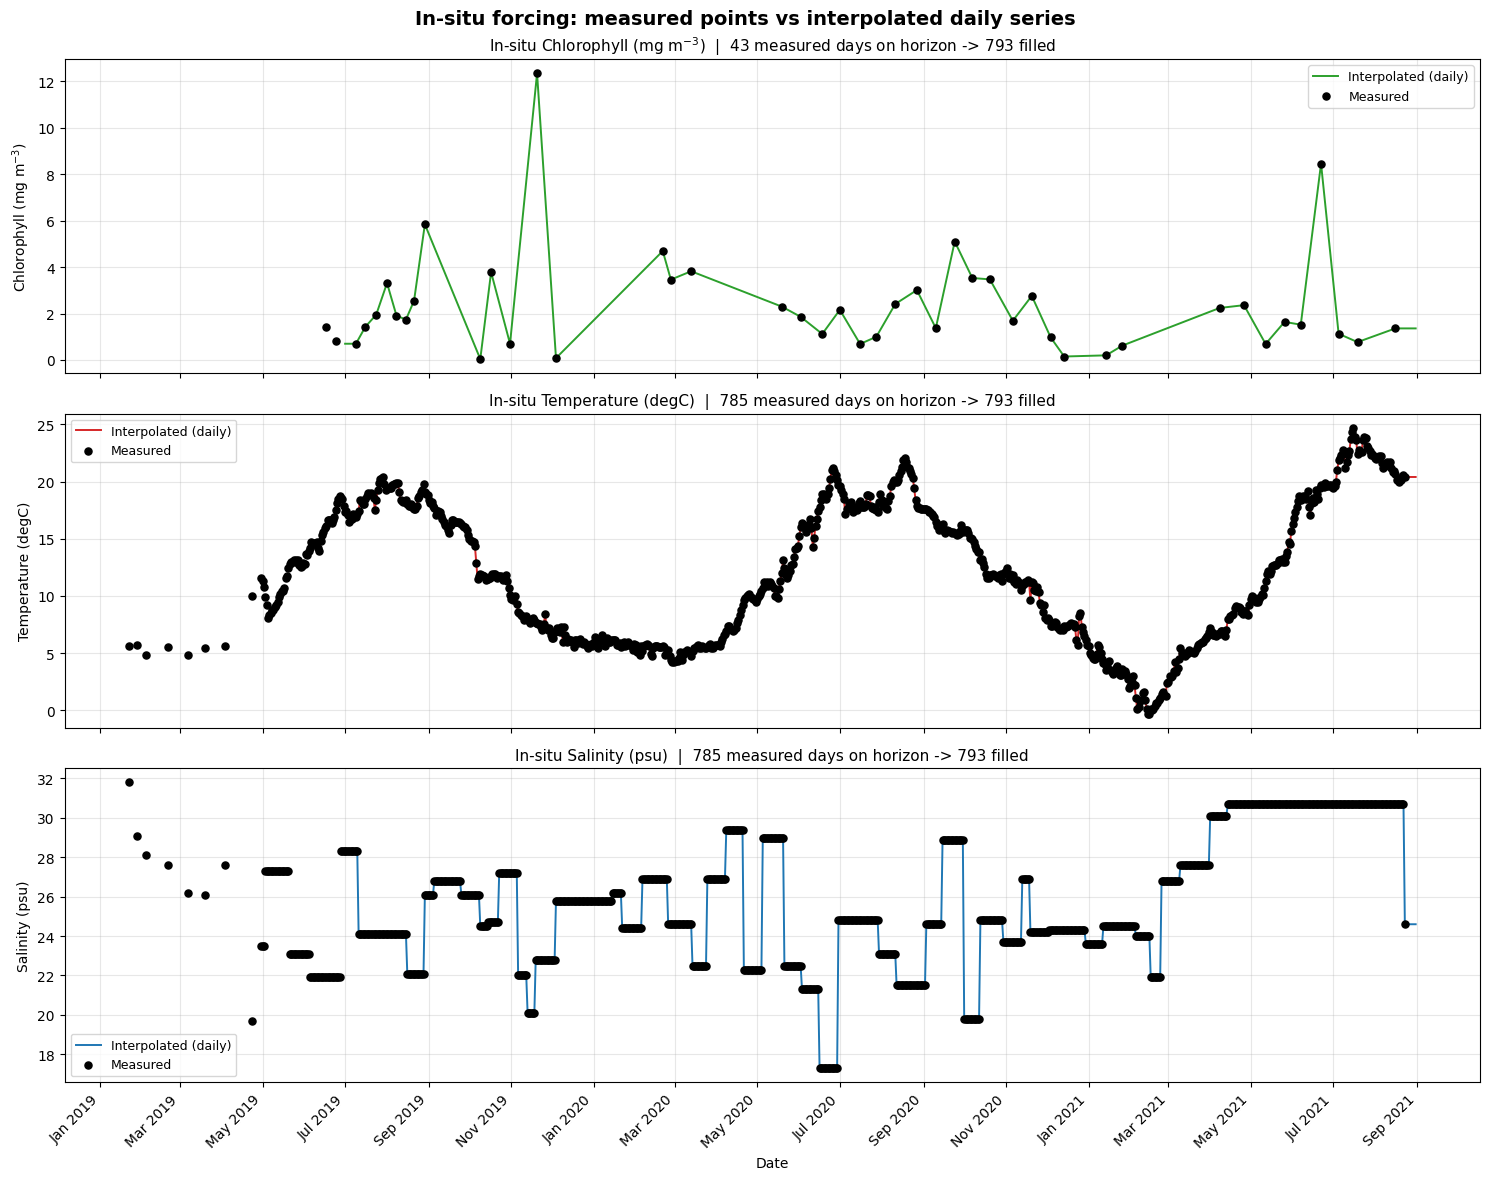

In [4]:
# ============================================================
# PLOT: RAW MEASUREMENTS vs INTERPOLATED DAILY SERIES
# ============================================================
specs = [
    ("Chl", "Chlorophyll (mg m$^{-3}$)", "tab:green"),
    ("T",   "Temperature (degC)",        "tab:red"),
    ("S",   "Salinity (psu)",            "tab:blue"),
]
var_of = {"Chl": "Chl", "T": "temperature", "S": "salinity"}

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for ax, (key, label, color) in zip(axes, specs):
    daily = ds_insitu[var_of[key]]
    ax.plot(pd.to_datetime(daily.time.values), daily.values, color=color, lw=1.4,
            label="Interpolated (daily)", zorder=3)
    rd = raw_insitu[key]
    ax.scatter(rd["date"], rd["value"], color="black", s=26, zorder=5,
               label="Measured")
    ax.set_ylabel(label)
    ax.set_title(f"In-situ {label}  |  {coverage[key]} measured days on horizon "
                 f"-> {len(daily)} filled", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for t in axes[-1].get_xticklabels():
    t.set_rotation(45); t.set_ha("right")
plt.suptitle("In-situ forcing: measured points vs interpolated daily series",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Run ShellSIM at the in-situ point

Same wrapper logic as the gridded run (forward-Euler, `partial_fabm.yaml`,
Chl-only prey) but applied to a single station's interpolated forcing.
`number_of_days_since_start_of_the_year` is updated each step so seasonal
physiology is correct across the full period.

In [5]:
# ============================================================
# SHELLSIM SINGLE-POINT WRAPPER (identical model to the gridded run)
# ============================================================
def run_shellsim_point(T_ts, S_ts, Chl_ts, days, config, log_filename):
    """Forward-Euler ShellSIM for one station time series.

    Returns (outputs, N_STATES) where outputs has shape (N_STATES+2, n):
      rows 0..N_STATES-1 : pyfabm state variables (model.state[:])
      row  N_STATES      : TFW diagnostic [g]
      row  N_STATES+1    : Shell Length diagnostic [cm]
    All-NaN from the step where any state first becomes non-finite.
    """
    T_ts   = np.asarray(T_ts, float)
    S_ts   = np.asarray(S_ts, float)
    Chl_ts = np.maximum(np.asarray(Chl_ts, float), 0.0)   # clamp unphysical < 0
    n = len(T_ts)

    with open(log_filename, "a") as f_log, redirect_stdout(f_log):
        model = pyfabm.Model(config)

        # static (time-invariant) dependencies
        model.cell_thickness = 1.0
        model.dependencies["seeding_rate"].value  = 0.0
        model.dependencies["harvest_ratio"].value = 0.0
        model.dependencies["current_speed"].value = 1.0
        model.dependencies["air_exposure"].value  = 0.0

        # initialise from day-0 forcing
        model.dependencies["temperature"].value        = float(T_ts[0])
        model.dependencies["practical_salinity"].value = float(S_ts[0])
        model.dependencies["number_of_days_since_start_of_the_year"].value = float(
            pd.Timestamp(days[0]).dayofyear)
        model.findStateVariable("Chl1/Chl").value = float(Chl_ts[0])

        if not model.start():
            raise RuntimeError(f"FABM failed to start: {pyfabm.getError()}")

        N_STATES = model.state[:].size
        outputs = np.full((N_STATES + 2, n), np.nan)

        for nd in range(n):
            model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                pd.Timestamp(days[nd]).dayofyear)
            model.dependencies["temperature"].value        = float(T_ts[nd])
            model.dependencies["practical_salinity"].value = float(S_ts[nd])
            model.findStateVariable("Chl1/Chl").value      = float(Chl_ts[nd])

            state_rates = model.getRates()
            model.state[:] += state_rates * 86400.0

            if not np.all(np.isfinite(np.array(model.state[:]))):
                break  # leave the rest NaN

            outputs[:N_STATES, nd]    = np.array(model.state[:])
            outputs[N_STATES, nd]     = model.diagnostic_variables["Oyster/TFW"].value
            outputs[N_STATES + 1, nd] = model.diagnostic_variables["Oyster/Shell_Length"].value

    return outputs, N_STATES

In [6]:
# ============================================================
# RUN ShellSIM on the interpolated in-situ forcing + SAVE
# ============================================================
outputs, N_STATES = run_shellsim_point(
    ds_insitu["temperature"].values,
    ds_insitu["salinity"].values,
    ds_insitu["Chl"].values,
    time_horizon,
    PYFABM_MODEL_CONFIG,
    RUN_LOG_FILENAME,
)
print(f"ShellSIM produced {N_STATES} state variables (+ TFW, SL).")

# Model output series (daily, indexed by date)
model_ste = pd.Series(outputs[0],            index=time_horizon, name="STE")
model_tfw = pd.Series(outputs[N_STATES],     index=time_horizon, name="TFW")
model_sl  = pd.Series(outputs[N_STATES + 1], index=time_horizon, name="SL")

def _rng(s):
    v = s.values[np.isfinite(s.values)]
    return (np.nan, np.nan) if v.size == 0 else (float(v.min()), float(v.max()))
print(f"TFW range: {_rng(model_tfw)[0]:.3f} -> {_rng(model_tfw)[1]:.3f} g")
print(f"SL  range: {_rng(model_sl)[0]:.3f} -> {_rng(model_sl)[1]:.3f} cm")

# Save output (single point)
ds_out_insitu = xr.Dataset(
    {
        "soft_tissue_energy": ("time", outputs[0]),
        "shell_energy":       ("time", outputs[1]),
        "TFW":                ("time", outputs[N_STATES]),
        "SL":                 ("time", outputs[N_STATES + 1]),
    },
    coords={"time": time_horizon, "latitude": point_lat, "longitude": point_lon},
)
ds_out_insitu["TFW"].attrs = {"units": "g",  "long_name": "Total Fresh Weight"}
ds_out_insitu["SL"].attrs  = {"units": "cm", "long_name": "Shell Length"}
ds_out_insitu.to_netcdf(output_file_name)
print(f"Saved ShellSIM (in-situ forced) output -> {output_file_name}")

ShellSIM produced 8 state variables (+ TFW, SL).
TFW range: 4.991 -> 861.113 g
SL  range: 3.757 -> 20.821 cm
Saved ShellSIM (in-situ forced) output -> insitu_output_timeseries.nc


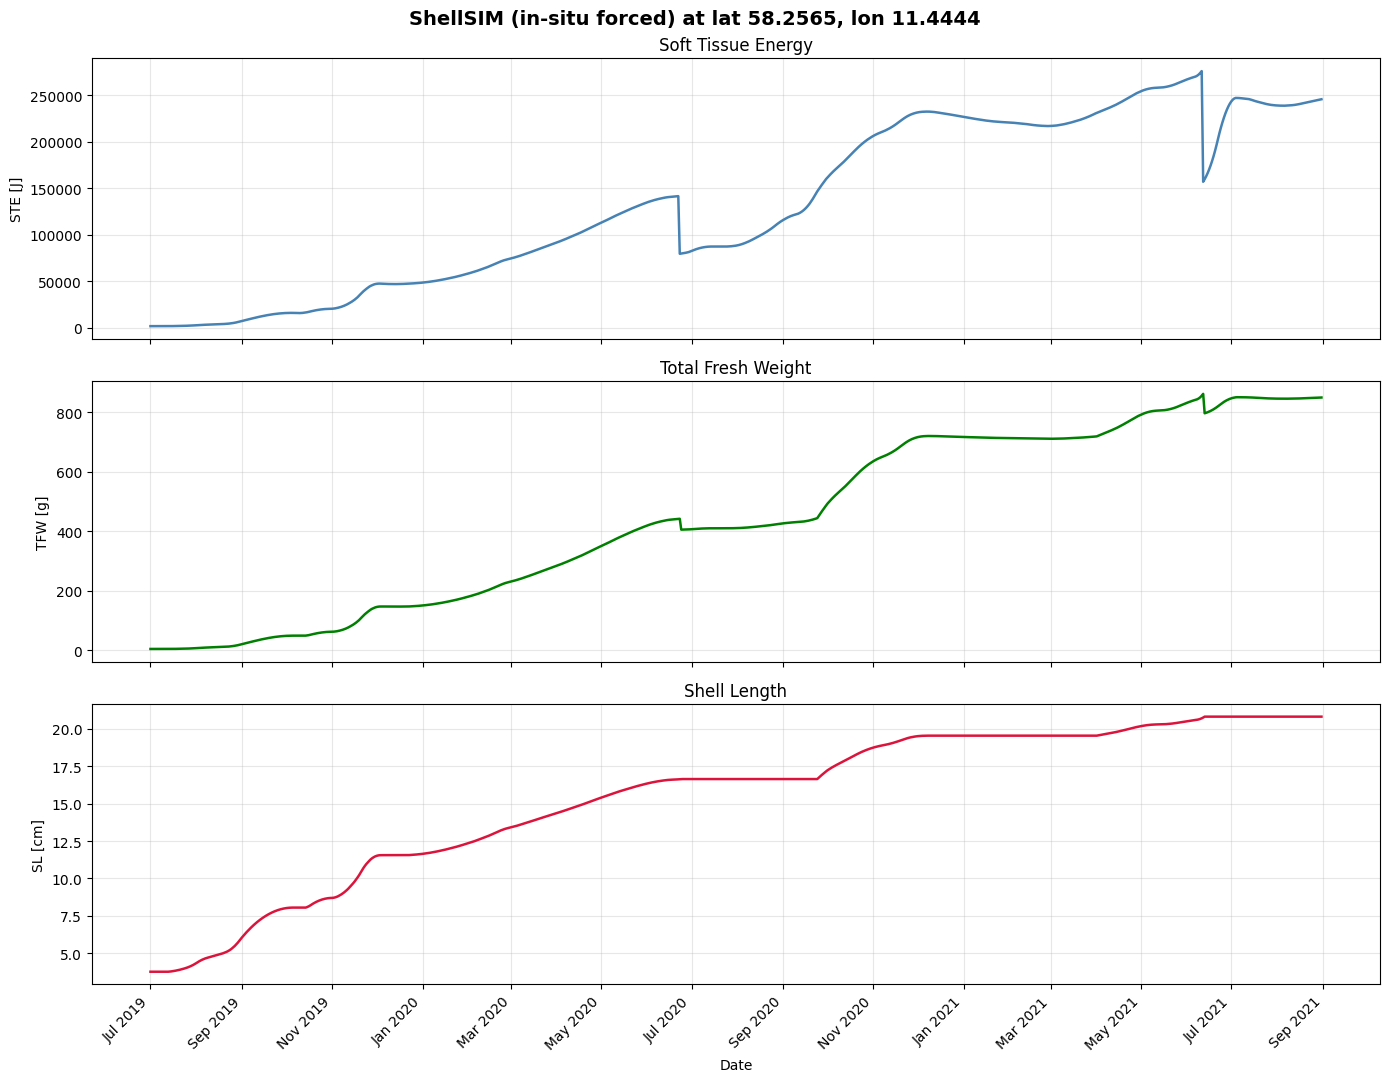

In [7]:
# ============================================================
# PLOT ShellSIM OUTPUTS (in-situ forced)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
axes[0].plot(time_horizon, model_ste.values, color="steelblue", lw=1.8)
axes[0].set_ylabel("STE [J]"); axes[0].set_title("Soft Tissue Energy")
axes[1].plot(time_horizon, model_tfw.values, color="green", lw=1.8)
axes[1].set_ylabel("TFW [g]"); axes[1].set_title("Total Fresh Weight")
axes[2].plot(time_horizon, model_sl.values, color="crimson", lw=1.8)
axes[2].set_ylabel("SL [cm]"); axes[2].set_title("Shell Length")
for ax in axes:
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for t in axes[-1].get_xticklabels():
    t.set_rotation(45); t.set_ha("right")
plt.suptitle(f"ShellSIM (in-situ forced) at lat {point_lat:.4f}, lon {point_lon:.4f}",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Compare outputs vs in-situ growth (MG / OE / ME)

Same comparison as the satellite notebook: modelled TFW & SL vs measured growth
for all three species (and size classes). The **satellite-forced** ShellSIM run
at the same point is overlaid where available, so the question — *is the issue
ShellSIM or the satellite inputs?* — can be read straight off the plot:

* in-situ-forced ≈ satellite-forced, both >> observations → **ShellSIM** over-grows
* in-situ-forced realistic but satellite-forced over-grows → **satellite inputs** (Chl)

In [8]:
# ============================================================
# LOAD IN-SITU GROWTH (TFW, SL) FOR ALL 3 SPECIES + satellite-forced overlay
# ============================================================
TFW_METRIC, SL_METRIC = "TFW (g)", "SL (cm)"
SPECIES_SHEET = {"MG": "CPr MG 3m", "OE": "CPr OE 3m", "ME": "CPr ME 3m"}
SPECIES_NAME  = {"MG": "Magallana gigas", "OE": "Ostrea edulis", "ME": "Mytilus edulis"}

def _load_species(sheet):
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet)
    df["date"] = pd.to_datetime(df["date"])
    if "size_class" not in df.columns:        # ME has no size class
        df["size_class"] = "all"
    return df

insitu_bio = {code: _load_species(sh) for code, sh in SPECIES_SHEET.items()}

def get_insitu_series(df, metric, size_class):
    sub = df[(df["metric"] == metric) & (df["size_class"] == size_class)].sort_values("date")
    return sub["date"].values, sub["value"].values.astype(float)

# Satellite-forced model output at the same point (for overlay / contrast)
sat_tfw = sat_sl = None
try:
    ds_sat = xr.open_dataset(SAT_OUTPUT_FILE).where(lambda d: d > -90)
    sat_pt = ds_sat.sel(latitude=point_lat, longitude=point_lon, method="nearest").load()
    sat_tfw = pd.Series(np.asarray(sat_pt["TFW"].values, float),
                        index=pd.to_datetime(sat_pt.time.values), name="sat_TFW")
    sat_sl  = pd.Series(np.asarray(sat_pt["SL"].values, float),
                        index=pd.to_datetime(sat_pt.time.values), name="sat_SL")
    print(f"Loaded satellite-forced output from {SAT_OUTPUT_FILE} for overlay.")
except Exception as e:
    print(f"(No satellite-forced overlay: {e})")

for code, df in insitu_bio.items():
    print(f"{code} ({SPECIES_NAME[code]:>16s}): {len(df):3d} rows, "
          f"size classes={sorted(df['size_class'].unique())}")

Loaded satellite-forced output from gridded_output_insitu_compare.nc for overlay.
MG ( Magallana gigas):  78 rows, size classes=['L', 'M', 'S']
OE (   Ostrea edulis):  66 rows, size classes=['L', 'M', 'S']
ME (  Mytilus edulis):  26 rows, size classes=['all']


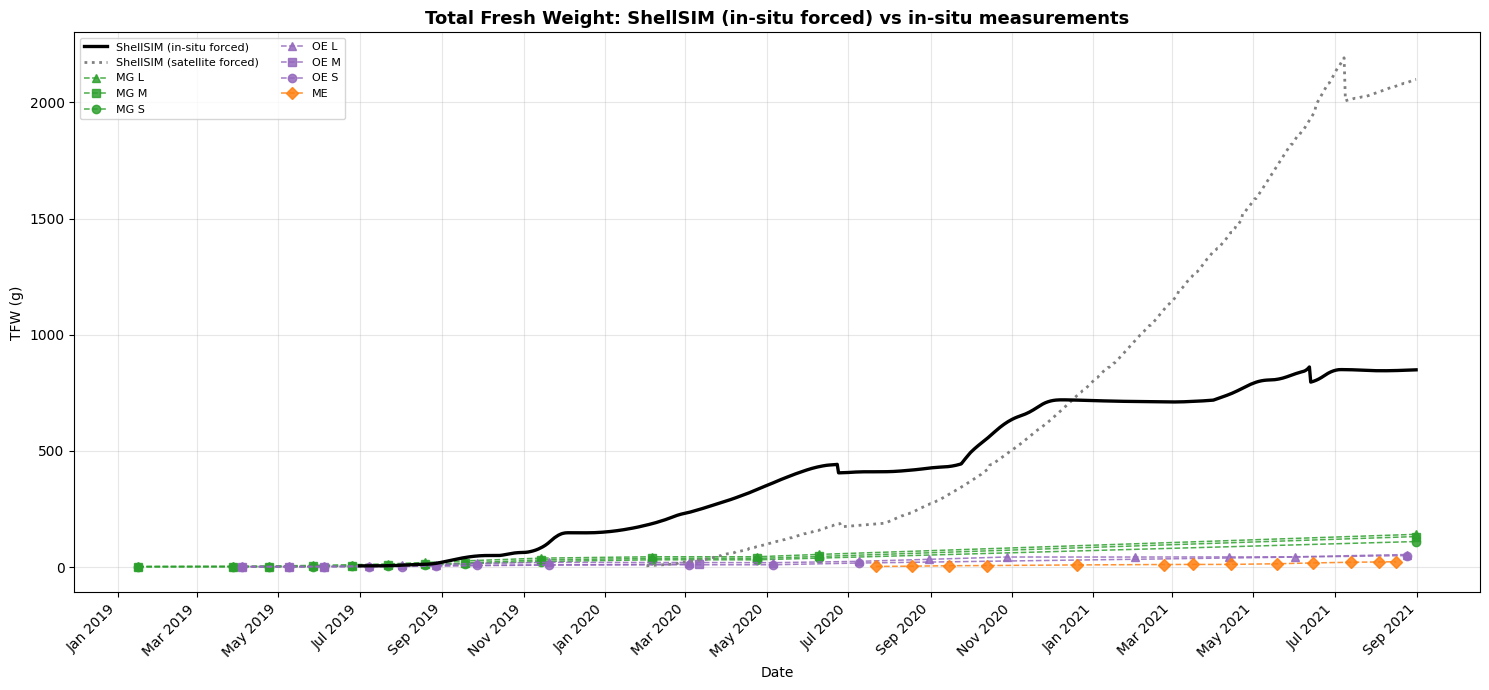

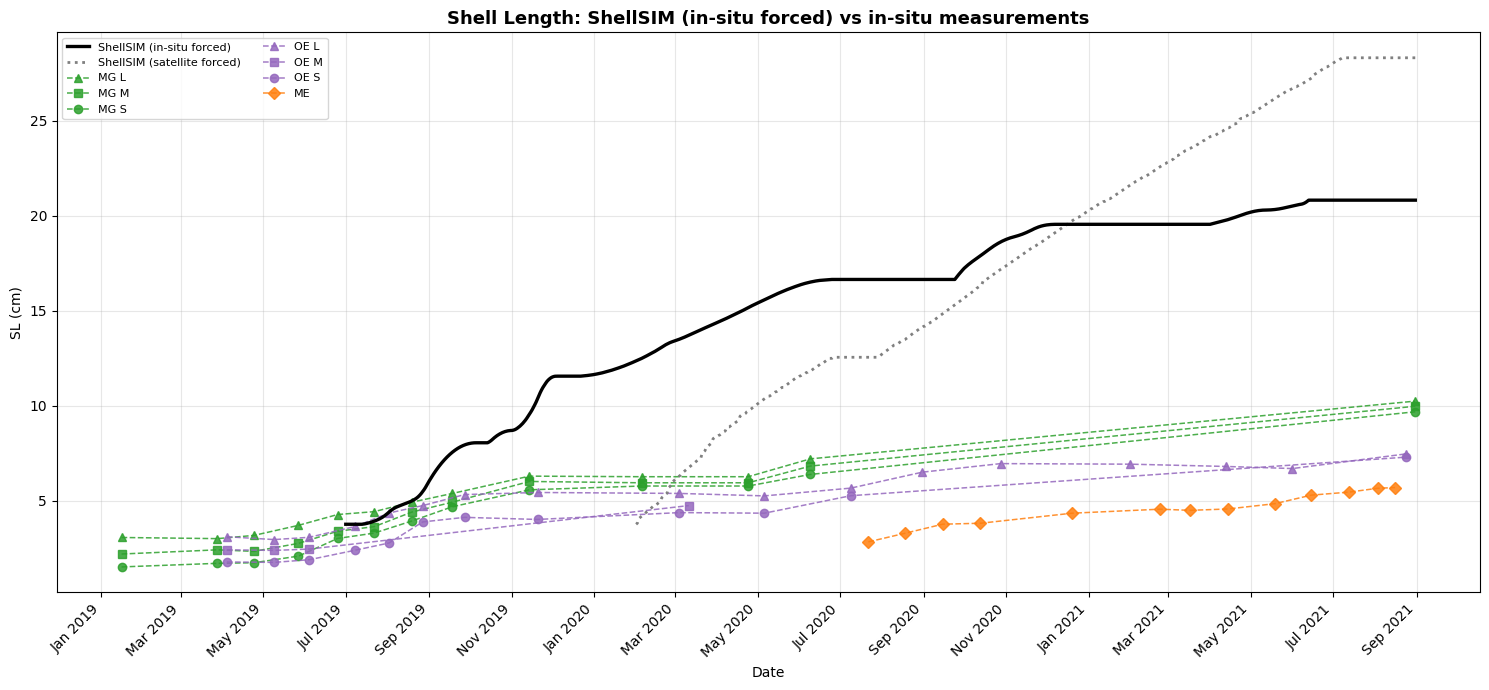

In [9]:
# ============================================================
# PLOT: MODEL (in-situ forced) vs IN-SITU GROWTH  [+ satellite-forced]
# ============================================================
size_markers   = {"S": "o", "M": "s", "L": "^", "all": "D"}
species_colors = {"MG": "tab:green", "OE": "tab:purple", "ME": "tab:orange"}

for metric, model_series, sat_series, ylab, title in [
    (TFW_METRIC, model_tfw, sat_tfw, "TFW (g)", "Total Fresh Weight"),
    (SL_METRIC,  model_sl,  sat_sl,  "SL (cm)", "Shell Length"),
]:
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(model_series.index, model_series.values, color="black", lw=2.4,
            label="ShellSIM (in-situ forced)", zorder=7)
    if sat_series is not None:
        ax.plot(sat_series.index, sat_series.values, color="grey", lw=2.0, ls=":",
                label="ShellSIM (satellite forced)", zorder=6)
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            lbl = f"{code} {sc}" if sc != "all" else code
            ax.plot(d, v, marker=size_markers.get(sc, "x"), ls="--", ms=6, lw=1.1,
                    color=species_colors[code], alpha=0.85, label=lbl)
    ax.set_ylabel(ylab); ax.set_xlabel("Date")
    ax.set_title(f"{title}: ShellSIM (in-situ forced) vs in-situ measurements",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    for t in ax.get_xticklabels():
        t.set_rotation(45); t.set_ha("right")
    plt.tight_layout()
    plt.show()

In [10]:
# ============================================================
# WHICH SPECIES DOES THE IN-SITU-FORCED MODEL TRACK BEST?
# ============================================================
# Sample each model trajectory at the in-situ sampling dates (nearest day,
# +/- tol_days) and score vs every cohort. Compare in-situ-forced AND
# satellite-forced RMSE side by side -> tells whether better inputs help.

def _match_model(model_series, dates, tol_days=7):
    s = model_series.dropna().sort_index()
    dates = pd.to_datetime(pd.Index(dates))
    out = np.full(len(dates), np.nan)
    if len(s):
        pos = s.index.get_indexer(dates, method="nearest")
        for k, (i, d) in enumerate(zip(pos, dates)):
            if i != -1 and abs((s.index[i] - d).days) <= tol_days:
                out[k] = s.iloc[i]
    return out

def _score(model_series, dates, obs):
    mod = _match_model(model_series, dates)
    obs = np.asarray(obs, float)
    m = np.isfinite(mod) & np.isfinite(obs)
    if m.sum() == 0:
        return None
    diff = mod[m] - obs[m]
    return dict(n=int(m.sum()),
                RMSE=float(np.sqrt(np.mean(diff**2))),
                MAE=float(np.mean(np.abs(diff))),
                bias=float(np.mean(diff)),
                r=float(np.corrcoef(mod[m], obs[m])[0, 1]) if m.sum() > 1 else np.nan)

rows = []
for metric, mser, sser in [(TFW_METRIC, model_tfw, sat_tfw), (SL_METRIC, model_sl, sat_sl)]:
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            sc_in = _score(mser, d, v)
            if sc_in is None:
                continue
            row = {"metric": metric, "species": code, "species_name": SPECIES_NAME[code],
                   "size_class": sc, "n": sc_in["n"],
                   "RMSE_insitu": sc_in["RMSE"], "MAE_insitu": sc_in["MAE"],
                   "bias_insitu": sc_in["bias"], "r_insitu": sc_in["r"]}
            if sser is not None:
                sc_sat = _score(sser, d, v)
                row["RMSE_sat"] = sc_sat["RMSE"] if sc_sat else np.nan
            rows.append(row)

cmp = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

for metric in [TFW_METRIC, SL_METRIC]:
    sub = cmp[cmp.metric == metric].sort_values("RMSE_insitu").reset_index(drop=True)
    print(f"\n{'='*84}\n  {metric}: in-situ-forced ShellSIM vs cohorts (sorted by RMSE_insitu)\n{'='*84}")
    if sub.empty:
        print("  No overlapping data."); continue
    show = [c for c in ["species", "species_name", "size_class", "n",
                        "RMSE_insitu", "MAE_insitu", "bias_insitu", "r_insitu", "RMSE_sat"]
            if c in sub.columns]
    print(sub[show].to_string(index=False))
    per_sp = sub.loc[sub.groupby("species")["RMSE_insitu"].idxmin()].sort_values("RMSE_insitu")
    best = per_sp.iloc[0]
    print(f"\n  Best match per species: " +
          ", ".join(f"{r.species}({r.size_class})={r.RMSE_insitu:.2f}" for _, r in per_sp.iterrows()))
    print(f"  => IN-SITU-FORCED model {metric} is CLOSEST to: {best.species} "
          f"({best.species_name}), size class '{best.size_class}'  [RMSE={best.RMSE_insitu:.3f}]")
    if "RMSE_sat" in sub.columns and sub["RMSE_sat"].notna().any():
        mi, ms = sub["RMSE_insitu"].mean(), sub["RMSE_sat"].mean()
        verdict = "IN-SITU forcing IMPROVES the fit" if mi < ms else "in-situ forcing does NOT improve the fit"
        print(f"  Mean RMSE across cohorts: in-situ-forced={mi:.2f}  vs  satellite-forced={ms:.2f}  -> {verdict}")


  TFW (g): in-situ-forced ShellSIM vs cohorts (sorted by RMSE_insitu)
species    species_name size_class  n  RMSE_insitu  MAE_insitu  bias_insitu  r_insitu  RMSE_sat
     OE   Ostrea edulis          M  1      234.143     234.143      234.143       NaN    16.661
     MG Magallana gigas          L  9      288.757     177.464      172.960     0.960   981.014
     MG Magallana gigas          M  9      294.029     180.890      180.462     0.960   986.097
     MG Magallana gigas          S  9      302.073     187.105      187.105     0.965   997.029
     OE   Ostrea edulis          S  9      329.528     214.006      214.006     0.945  1022.033
     OE   Ostrea edulis          L 14      462.778     356.432      356.416     0.965  1075.869
     ME  Mytilus edulis        all 13      686.462     668.479      668.479     0.909  1376.387

  Best match per species: OE(M)=234.14, MG(L)=288.76, ME(all)=686.46
  => IN-SITU-FORCED model TFW (g) is CLOSEST to: OE (Ostrea edulis), size class 'M'  [RMSE=

## 4. Diagnosis — ShellSIM vs satellite inputs

Read the result off the comparison above:

| Observation | Conclusion |
|---|---|
| In-situ-forced growth ≈ satellite-forced growth, both far above measured TFW/SL | The over-growth is intrinsic to **ShellSIM** (parameters / seed / lack of POC-POM-TPM food limitation), not the satellite inputs |
| In-situ-forced growth is realistic but satellite-forced over-grows | The problem is the **satellite forcing** — most likely the noisy / biased Chl (RMSE ≈ 2.3, r ≈ 0.16) inflating the food signal |
| Both under/over by a steady factor | A calibration/seed-size offset rather than a forcing problem |

**Next levers if ShellSIM itself over-grows:** revisit `seed_TFW`, the death/target-energy
parameters, and whether Chl-only prey (no POC/POM/TPM) removes a limiting factor that would
otherwise cap growth; consider tuning to the MG cohort, since `partial_fabm.yaml` is *M. gigas*.

---
## 5. Full-input run — add POM + TPM (POC excluded)

Read the extra food variables from sheet **`CPr food TPM POM 3m`** and gap-fill
them the same way (`extract_filled_insitu.load_filled_insitu_full`). These feed
the `full_fabm.yaml` config.

**POC is excluded** — it is all zeros in the workbook (not measured in the
Culture Project), so it has been set `prey2isPOC: false` and commented out in
`full_fabm.yaml`. The full run therefore couples **Chl + POM + TPM** (`nprey: 4`,
POC slot 2 disabled).

**Units:** POM/TPM magnitudes (~0.5–14) are physical only as **mg/L (= g m⁻³)**,
which is what ShellSIM expects, so they are used directly (no ×1000). The
metadata's "g/L" label is treated as mg/L; change `food_unit_factor` if wrong.

> If FABM errors at start about a missing `prey2` coupling, your build requires
> contiguous prey slots — re-enable `prey2: POC1` coupled to a zero POC module,
> or renumber. The notebook flags a clean start either way.

In [45]:
# ============================================================
# BUILD FULL IN-SITU FORCING (T, S, Chl, POC, POM, TPM) + SAVE
# ============================================================
from extract_filled_insitu import load_filled_insitu_full

PYFABM_FULL_CONFIG = "/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/notebook_dropdowns/final_working_versions/full_fabm.yaml"
FULL_INPUT_FILE    = "insitu_input_timeseries_full.nc"
FULL_OUTPUT_FILE   = "insitu_output_timeseries_full.nc"

ds_insitu_full, raw_full, coverage_full = load_filled_insitu_full(
    EXCEL_FILE,
    time_range=(start_date, end_date),
    latitude=point_lat,
    longitude=point_lon,
    interp_method="linear",
    clip_negative=True,
    food_unit_factor=1.0,   # POM/TPM treated as mg/L (= g m-3); set 1000.0 if truly g/L
    verbose=True,
)
ds_insitu_full.to_netcdf(FULL_INPUT_FILE)
print(f"\nSaved full in-situ forcing -> {FULL_INPUT_FILE}")
ds_insitu_full

Daily horizon: 2019-07-01 -> 2021-08-31 (793 days)
  T  :  785 measured days on horizon -> filled to 793
  S  :  785 measured days on horizon -> filled to 793
  Chl:   43 measured days on horizon -> filled to 793
  POC:   49 measured days on horizon -> filled to 793
  POM:   49 measured days on horizon -> filled to 793
  TPM:   49 measured days on horizon -> filled to 793
  NOTE: POC is all zeros (not measured) -> POC food channel is effectively off.

Saved full in-situ forcing -> insitu_input_timeseries_full.nc


<xarray.Dataset> Size: 25kB
Dimensions:      (time: 793)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2019-07-01 2019-07-02 ... 2021-08-31
    latitude     float64 8B 58.26
    longitude    float64 8B 11.44
Data variables:
    temperature  (time) float32 3kB 17.3 17.4 17.1 16.5 ... 20.4 20.4 20.4 20.4
    salinity     (time) float32 3kB 28.3 28.3 28.3 28.3 ... 24.6 24.6 24.6 24.6
    Chl          (time) float32 3kB 0.7 0.7 0.7 0.7 0.7 ... 1.36 1.36 1.36 1.36
    POC          (time) float32 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    POM          (time) float32 3kB 1.95 1.95 1.95 1.952 ... 2.59 2.59 2.59 2.59
    TPM          (time) float32 3kB 5.01 5.01 5.01 5.128 ... 11.77 11.77 11.77

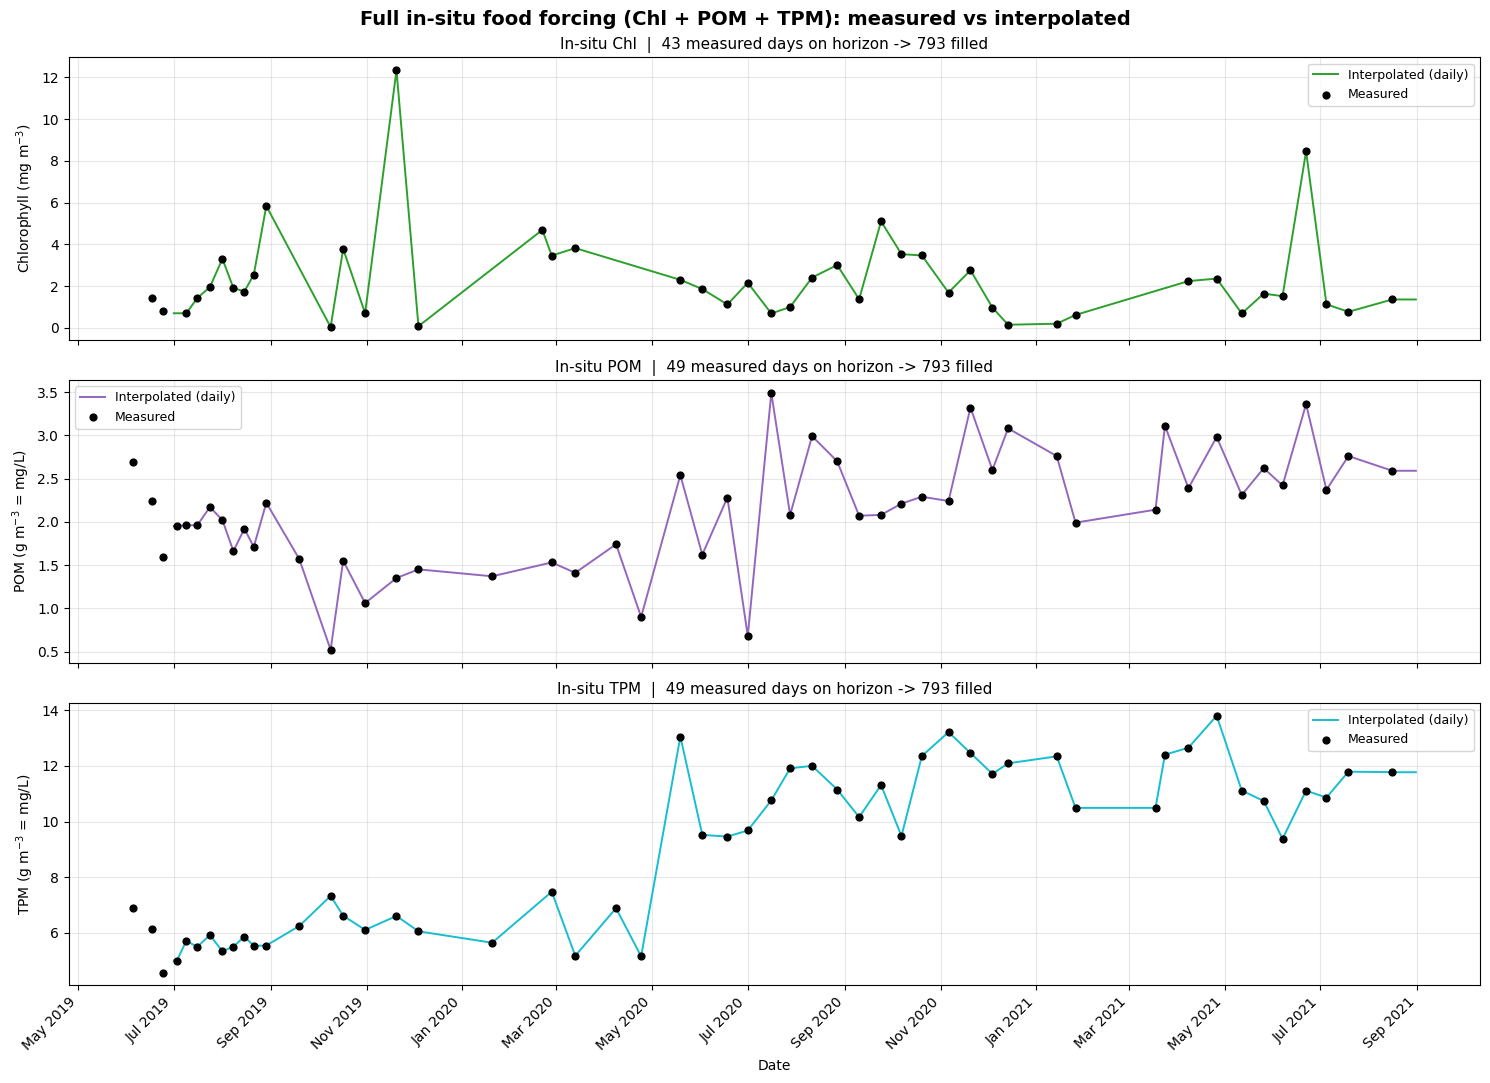

In [46]:
# ============================================================
# PLOT: RAW vs INTERPOLATED for the food variables fed to ShellSIM
# ============================================================
# POC is omitted here — it is all zeros (unmeasured) and excluded from the model.
food_specs = [
    ("Chl", "Chl", "Chlorophyll (mg m$^{-3}$)", "tab:green"),
    ("POM", "POM", "POM (g m$^{-3}$ = mg/L)",   "tab:purple"),
    ("TPM", "TPM", "TPM (g m$^{-3}$ = mg/L)",   "tab:cyan"),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)
for ax, (rawkey, var, label, color) in zip(axes, food_specs):
    daily = ds_insitu_full[var]
    ax.plot(pd.to_datetime(daily.time.values), daily.values, color=color, lw=1.4,
            label="Interpolated (daily)", zorder=3)
    rd = raw_full[rawkey]
    ax.scatter(rd["date"], rd["value"], color="black", s=24, zorder=5, label="Measured")
    ax.set_ylabel(label)
    ax.set_title(f"In-situ {var}  |  {coverage_full[rawkey]} measured days on horizon "
                 f"-> {len(daily)} filled", fontsize=11)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for t in axes[-1].get_xticklabels():
    t.set_rotation(45); t.set_ha("right")
plt.suptitle("Full in-situ food forcing (Chl + POM + TPM): measured vs interpolated",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Run ShellSIM with full inputs (`full_fabm.yaml`)

Same forward-Euler loop, but the model couples all four prey and we set
`Chl1/Chl`, `POC1/POC`, `POM1/POM`, `TPM1/TPM` each day from the interpolated
in-situ food series.

In [47]:
# ============================================================
# SHELLSIM SINGLE-POINT WRAPPER — Chl + POM + TPM (POC excluded)
# ============================================================
def run_shellsim_point_full(T_ts, S_ts, Chl_ts, POM_ts, TPM_ts,
                            days, config, log_filename):
    """Forward-Euler ShellSIM for one station, setting Chl + POM + TPM each day.
    (POC is excluded — disabled/commented out in full_fabm.yaml.)
    Returns (outputs, N_STATES) with outputs shape (N_STATES+2, n):
    rows 0..N_STATES-1 = states, row N_STATES = TFW [g], row N_STATES+1 = SL [cm]."""
    T_ts   = np.asarray(T_ts, float)
    S_ts   = np.asarray(S_ts, float)
    Chl_ts = np.maximum(np.asarray(Chl_ts, float), 0.0)
    POM_ts = np.maximum(np.asarray(POM_ts, float), 0.0)
    TPM_ts = np.maximum(np.asarray(TPM_ts, float), 0.0)
    n = len(T_ts)

    with open(log_filename, "a") as f_log, redirect_stdout(f_log):
        model = pyfabm.Model(config)

        model.cell_thickness = 1.0
        model.dependencies["seeding_rate"].value  = 0.0
        model.dependencies["harvest_ratio"].value = 0.0
        model.dependencies["current_speed"].value = 1.0
        model.dependencies["air_exposure"].value  = 0.0

        model.dependencies["temperature"].value        = float(T_ts[0])
        model.dependencies["practical_salinity"].value = float(S_ts[0])
        model.dependencies["number_of_days_since_start_of_the_year"].value = float(
            pd.Timestamp(days[0]).dayofyear)
        model.findStateVariable("Chl1/Chl").value = float(Chl_ts[0])
        model.findStateVariable("POM1/POM").value = float(POM_ts[0])
        model.findStateVariable("TPM1/TPM").value = float(TPM_ts[0])

        if not model.start():
            raise RuntimeError(f"FABM failed to start: {pyfabm.getError()}")

        N_STATES = model.state[:].size
        outputs = np.full((N_STATES + 2, n), np.nan)

        for nd in range(n):
            model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                pd.Timestamp(days[nd]).dayofyear)
            model.dependencies["temperature"].value        = float(T_ts[nd])
            model.dependencies["practical_salinity"].value = float(S_ts[nd])
            model.findStateVariable("Chl1/Chl").value = float(Chl_ts[nd])
            model.findStateVariable("POM1/POM").value = float(POM_ts[nd])
            model.findStateVariable("TPM1/TPM").value = float(TPM_ts[nd])

            state_rates = model.getRates()
            model.state[:] += state_rates * 86400.0

            if not np.all(np.isfinite(np.array(model.state[:]))):
                break

            outputs[:N_STATES, nd]    = np.array(model.state[:])
            outputs[N_STATES, nd]     = model.diagnostic_variables["Oyster/TFW"].value
            outputs[N_STATES + 1, nd] = model.diagnostic_variables["Oyster/Shell_Length"].value

    return outputs, N_STATES

In [48]:
# ============================================================
# RUN ShellSIM (full inputs: Chl + POM + TPM) + SAVE
# ============================================================
outputs_full, N_STATES_FULL = run_shellsim_point_full(
    ds_insitu_full["temperature"].values,
    ds_insitu_full["salinity"].values,
    ds_insitu_full["Chl"].values,
    ds_insitu_full["POM"].values,
    ds_insitu_full["TPM"].values,
    time_horizon,
    PYFABM_FULL_CONFIG,
    RUN_LOG_FILENAME,
)
print(f"Full-input ShellSIM produced {N_STATES_FULL} state variables (+ TFW, SL).")

model_ste_full = pd.Series(outputs_full[0],                 index=time_horizon, name="STE_full")
model_tfw_full = pd.Series(outputs_full[N_STATES_FULL],     index=time_horizon, name="TFW_full")
model_sl_full  = pd.Series(outputs_full[N_STATES_FULL + 1], index=time_horizon, name="SL_full")

print(f"TFW (full) range: {np.nanmin(model_tfw_full):.3f} -> {np.nanmax(model_tfw_full):.3f} g")
print(f"SL  (full) range: {np.nanmin(model_sl_full):.3f} -> {np.nanmax(model_sl_full):.3f} cm")

ds_out_full = xr.Dataset(
    {
        "soft_tissue_energy": ("time", outputs_full[0]),
        "shell_energy":       ("time", outputs_full[1]),
        "TFW":                ("time", outputs_full[N_STATES_FULL]),
        "SL":                 ("time", outputs_full[N_STATES_FULL + 1]),
    },
    coords={"time": time_horizon, "latitude": point_lat, "longitude": point_lon},
)
ds_out_full["TFW"].attrs = {"units": "g",  "long_name": "Total Fresh Weight (Chl+POM+TPM)"}
ds_out_full["SL"].attrs  = {"units": "cm", "long_name": "Shell Length (Chl+POM+TPM)"}
ds_out_full.to_netcdf(FULL_OUTPUT_FILE)
print(f"Saved ShellSIM (full inputs) output -> {FULL_OUTPUT_FILE}")

Full-input ShellSIM produced 10 state variables (+ TFW, SL).
TFW (full) range: 4.974 -> 56.772 g
SL  (full) range: 3.757 -> 8.440 cm
Saved ShellSIM (full inputs) output -> insitu_output_timeseries_full.nc


## 7. Three-way comparison

Three model trajectories against the measured growth of MG / OE / ME:

1. **ShellSIM (in-situ, Chl-only)** — `partial_fabm.yaml`, in-situ forcing
2. **ShellSIM (in-situ, full inputs)** — `full_fabm.yaml`, in-situ Chl + POC + POM + TPM
3. **ShellSIM (satellite forced)** — from the gridded satellite run

If (1) and (2) overlap, the extra food variables make no difference (consistent
with `nprey: 1` / unmeasured POC). If all three model lines sit far above the
measured cohorts, the over-growth is intrinsic to ShellSIM, not the inputs.

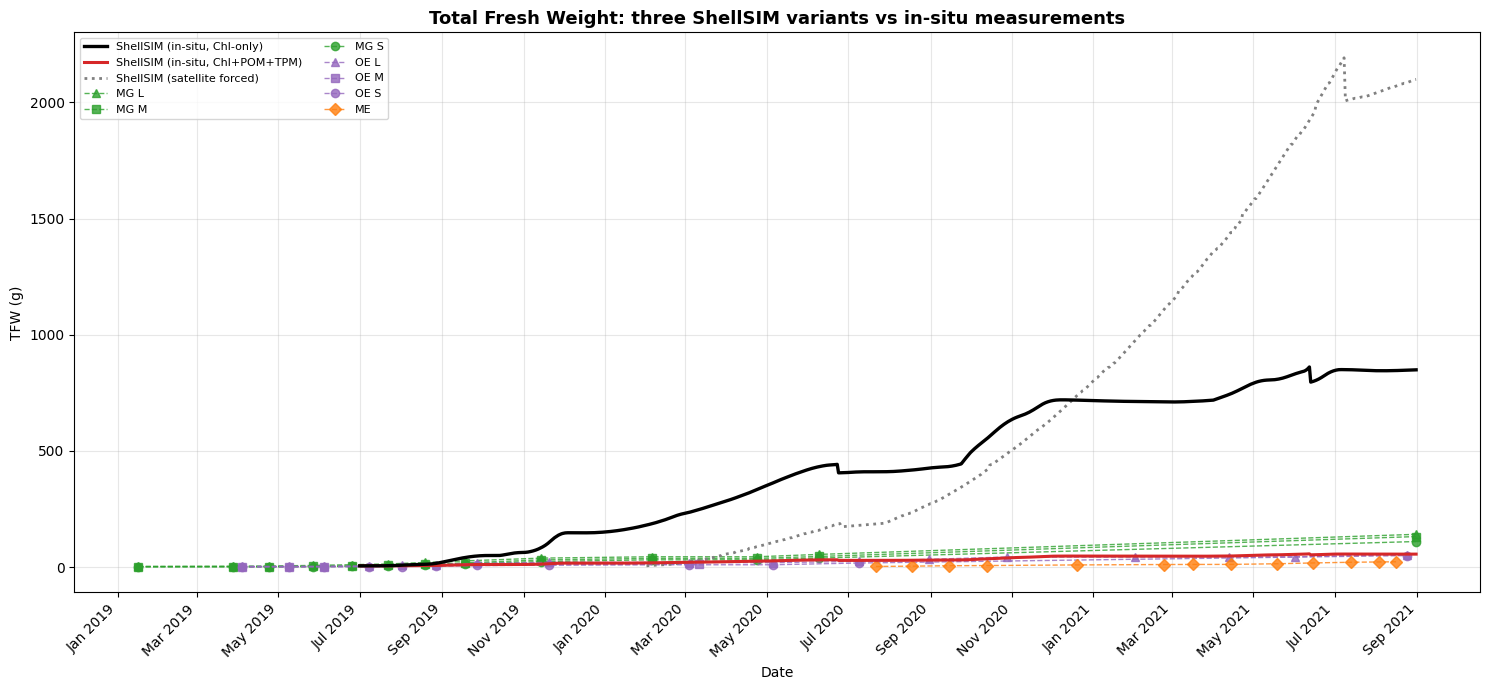

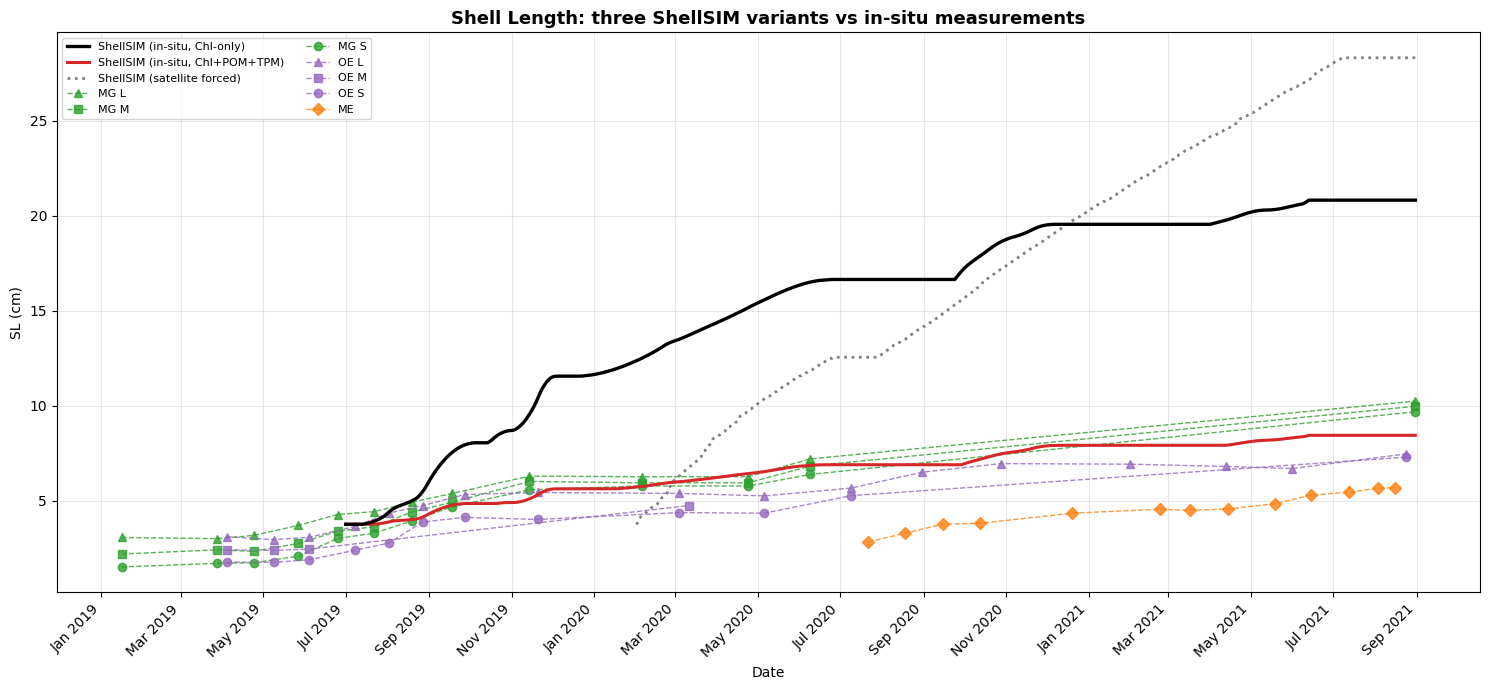

Max |full - chl-only| difference:  TFW=804.3 g,  SL=12.38 cm


In [51]:
# ============================================================
# THREE-WAY COMPARISON PLOT vs IN-SITU GROWTH
#   1) ShellSIM in-situ, Chl-only   (model_tfw / model_sl)
#   2) ShellSIM in-situ, full inputs (model_tfw_full / model_sl_full)
#   3) ShellSIM satellite forced     (sat_tfw / sat_sl, if available)
# ============================================================
# reuse size_markers / species_colors / insitu_bio / get_insitu_series from sec.3
for metric, m_chl, m_full, m_sat, ylab, title in [
    (TFW_METRIC, model_tfw, model_tfw_full, sat_tfw, "TFW (g)", "Total Fresh Weight"),
    (SL_METRIC,  model_sl,  model_sl_full,  sat_sl,  "SL (cm)", "Shell Length"),
]:
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(m_chl.index,  m_chl.values,  color="black",   lw=2.4,
            label="ShellSIM (in-situ, Chl-only)", zorder=8)
    ax.plot(m_full.index, m_full.values, color="tab:red", lw=2.2, ls="-",
            label="ShellSIM (in-situ, Chl+POM+TPM)", zorder=7)
    if m_sat is not None:
        ax.plot(m_sat.index, m_sat.values, color="grey", lw=2.0, ls=":",
                label="ShellSIM (satellite forced)", zorder=6)
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            lbl = f"{code} {sc}" if sc != "all" else code
            ax.plot(d, v, marker=size_markers.get(sc, "x"), ls="--", ms=6, lw=1.0,
                    color=species_colors[code], alpha=0.8, label=lbl)
    ax.set_ylabel(ylab); ax.set_xlabel("Date")
    ax.set_title(f"{title}: three ShellSIM variants vs in-situ measurements",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    for t in ax.get_xticklabels():
        t.set_rotation(45); t.set_ha("right")
    plt.tight_layout()
    plt.show()

# Quick check: did the extra food change anything vs Chl-only?
dtfw = float(np.nanmax(np.abs(model_tfw_full.values - model_tfw.values)))
dsl  = float(np.nanmax(np.abs(model_sl_full.values - model_sl.values)))
print(f"Max |full - chl-only| difference:  TFW={dtfw:.4g} g,  SL={dsl:.4g} cm")
if dtfw < 1e-6 and dsl < 1e-6:
    print("=> Full and Chl-only are IDENTICAL: POM/TPM are not affecting growth "
          "(check that full_fabm.yaml actually feeds them, e.g. nprey / prey flags).")

In [52]:
# ============================================================
# THREE-WAY SKILL TABLE: which variant tracks each species best?
# ============================================================
# Reuses _match_model / _score from section 3 (must have been run).
variants = [("chl_only", model_tfw, model_sl),
            ("full",     model_tfw_full, model_sl_full)]
if sat_tfw is not None:
    variants.append(("satellite", sat_tfw, sat_sl))

rows3 = []
for metric, sl_flag in [(TFW_METRIC, False), (SL_METRIC, True)]:
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            row = {"metric": metric, "species": code, "size_class": sc}
            ok = False
            for vname, mtfw, msl in variants:
                sc_res = _score(msl if sl_flag else mtfw, d, v)
                if sc_res is not None:
                    row[f"RMSE_{vname}"] = sc_res["RMSE"]
                    row["n"] = sc_res["n"]
                    ok = True
            if ok:
                rows3.append(row)

cmp3 = pd.DataFrame(rows3)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
rmse_cols = [c for c in cmp3.columns if c.startswith("RMSE_")]

for metric in [TFW_METRIC, SL_METRIC]:
    sub = cmp3[cmp3.metric == metric].copy()
    if sub.empty:
        continue
    sub = sub.sort_values(rmse_cols[0]).reset_index(drop=True)
    print(f"\n{'='*80}\n  {metric}: RMSE by variant (lower = closer to that cohort)\n{'='*80}")
    print(sub[["species", "size_class", "n"] + rmse_cols].to_string(index=False))
    print("  Mean RMSE across cohorts:")
    for c in rmse_cols:
        print(f"    {c:16s} = {sub[c].mean():.3f}")
    best_variant = min(rmse_cols, key=lambda c: sub[c].mean())
    print(f"  => Best overall forcing for {metric}: {best_variant.replace('RMSE_','')}")

print("\nVerdict guide:")
print("  - full ~= chl_only  -> POM/TPM not changing growth (model/config), not the inputs")
print("  - in-situ variants << satellite RMSE -> satellite Chl was inflating growth")
print("  - all variants >> observations -> over-growth is intrinsic to ShellSIM")


  TFW (g): RMSE by variant (lower = closer to that cohort)
species size_class  n  RMSE_chl_only  RMSE_full  RMSE_satellite
     OE          M  1        234.143      8.400          16.661
     MG          L  4        288.757     33.423         981.014
     MG          M  4        294.029     27.587         986.097
     MG          S  4        302.073     19.252         997.029
     OE          S  4        329.528      8.297        1022.033
     OE          L  9        462.778      4.814        1075.869
     ME        all 13        686.462     33.050        1376.387
  Mean RMSE across cohorts:
    RMSE_chl_only    = 371.110
    RMSE_full        = 19.260
    RMSE_satellite   = 922.156
  => Best overall forcing for TFW (g): full

  SL (cm): RMSE by variant (lower = closer to that cohort)
species size_class  n  RMSE_chl_only  RMSE_full  RMSE_satellite
     MG          L  4          6.078      0.882           9.545
     MG          M  4          6.320      0.649           9.734
     MG     

---
## 8. Hybrid forcing — satellite Chl / T / S + in-situ POM + TPM

The in-situ runs (§1–7) answered the first question: with **in-situ** forcing —
especially once **POM + TPM** are added (§5–7) — ShellSIM tracks the measured
cohorts well, so the model itself is not the problem. This section attacks the
second question with a sharper test.

The satellite product only delivers **Chl, temperature, salinity** — it has no
POM/TPM. So I build a **hybrid forcing**:

| Channel | Source |
|---|---|
| **Chl, temperature, salinity** | **satellite**, sampled at the in-situ point from `gridded_input_insitu_compare.nc` |
| **POM, TPM** | **in-situ** interpolated food series (§5) — the only source available |

and feed it to the same **`full_fabm.yaml`** model (Chl + POM + TPM). This
isolates the effect of the satellite Chl/T/S *while keeping realistic food
limitation* from the in-situ POM/TPM:

* **hybrid ≈ in-situ-full, and ≪ satellite-forced** → the satellite over-growth
  was mainly the **missing POM/TPM food limitation**; the satellite Chl/T/S are
  usable once that limitation is restored.
* **hybrid still ≫ observations (tracks the satellite line)** → the satellite
  **Chl/T/S themselves** drive the over-growth (satellite Chl over this window
  averages ~3.3 vs ~2.2 mg m⁻³ in-situ), even with realistic POM/TPM.

**Run window** = the satellite period **2020-02-01 → 2021-08-31**, seeded at the
same 5 g as the satellite-forced run, so *hybrid* and *satellite-forced* are
strictly apples-to-apples (identical seed and start day). The in-situ-full and
Chl-only lines began in 2019-07, so over this window they show their
already-grown continuation — the realistic reference trajectory. The resulting
**4-line** plot (hybrid, satellite, in-situ-full, in-situ-Chl-only) is restricted
to the satellite period and overlaid on the measured MG / OE / ME cohorts.


In [53]:
# ============================================================
# BUILD HYBRID FORCING: satellite Chl/T/S (at the in-situ point) + in-situ POM/TPM
# ============================================================
SAT_INPUT_FILE     = "gridded_input_insitu_compare.nc"      # satellite gridded forcing
HYBRID_INPUT_FILE  = "insitu_input_timeseries_hybrid.nc"
HYBRID_OUTPUT_FILE = "insitu_output_timeseries_hybrid.nc"

# --- satellite Chl / T / S sampled at the in-situ point ---
ds_sat_in = xr.open_dataset(SAT_INPUT_FILE)
sat_pt_in = ds_sat_in.sel(latitude=point_lat, longitude=point_lon, method="nearest").load()

# Satellite horizon = the period we actually have satellite data for. Using it (rather
# than the full in-situ horizon) means the hybrid run starts from the same 5 g seed on
# the same day as the satellite-forced run -> the two are directly comparable.
sat_horizon = pd.to_datetime(sat_pt_in.time.values)
print(f"Satellite window: {sat_horizon[0].date()} -> {sat_horizon[-1].date()} ({len(sat_horizon)} days)")

sat_T   = np.asarray(sat_pt_in["temperature"].values, float)
sat_S   = np.asarray(sat_pt_in["salinity"].values,    float)
sat_Chl = np.asarray(sat_pt_in["Chl"].values,         float)

# --- in-situ POM / TPM, sampled onto the satellite horizon ---
# ds_insitu_full (sec.5) is daily over the full in-situ horizon; the satellite window
# is a subset of it, and in-situ POM/TPM are measured 2019-06 -> 2021-08, so this
# window is fully bracketed by real food measurements.
hyb_POM = np.asarray(ds_insitu_full["POM"].sel(time=sat_horizon, method="nearest").values, float)
hyb_TPM = np.asarray(ds_insitu_full["TPM"].sel(time=sat_horizon, method="nearest").values, float)

# --- assemble the hybrid forcing dataset ---
ds_hybrid = xr.Dataset(
    {
        "temperature": ("time", sat_T.astype("float32")),
        "salinity":    ("time", sat_S.astype("float32")),
        "Chl":         ("time", sat_Chl.astype("float32")),
        "POM":         ("time", hyb_POM.astype("float32")),
        "TPM":         ("time", hyb_TPM.astype("float32")),
    },
    coords={"time": sat_horizon, "latitude": point_lat, "longitude": point_lon},
)
ds_hybrid["temperature"].attrs = {"units": "degC",        "long_name": "SATELLITE temperature at in-situ point"}
ds_hybrid["salinity"].attrs    = {"units": "psu",         "long_name": "SATELLITE salinity at in-situ point"}
ds_hybrid["Chl"].attrs         = {"units": "mg m-3",      "long_name": "SATELLITE chlorophyll at in-situ point"}
ds_hybrid["POM"].attrs         = {"units": "g m-3 (mg/L)", "long_name": "IN-SITU POM (interpolated)"}
ds_hybrid["TPM"].attrs         = {"units": "g m-3 (mg/L)", "long_name": "IN-SITU TPM (interpolated)"}
ds_hybrid.to_netcdf(HYBRID_INPUT_FILE)
print(f"Saved hybrid forcing -> {HYBRID_INPUT_FILE}")

# Sanity contrast: satellite Chl vs in-situ Chl over the same window (drives the story)
insitu_chl_win = ds_insitu_full["Chl"].sel(time=sat_horizon, method="nearest").values
print(f"Chl over window:  satellite mean={np.nanmean(sat_Chl):.2f}  vs  "
      f"in-situ mean={np.nanmean(insitu_chl_win):.2f}  (mg m-3)")
ds_hybrid


Satellite window: 2020-02-01 -> 2021-08-31 (578 days)
Saved hybrid forcing -> insitu_input_timeseries_hybrid.nc
Chl over window:  satellite mean=3.31  vs  in-situ mean=2.15  (mg m-3)


<xarray.Dataset> Size: 16kB
Dimensions:      (time: 578)
Coordinates:
  * time         (time) datetime64[ns] 5kB 2020-02-01 2020-02-02 ... 2021-08-31
    latitude     float64 8B 58.26
    longitude    float64 8B 11.44
Data variables:
    temperature  (time) float32 2kB 12.21 12.21 12.21 12.21 ... 12.8 16.63 12.38
    salinity     (time) float32 2kB 28.39 27.94 28.1 26.77 ... 26.52 25.1 24.69
    Chl          (time) float32 2kB 3.324 11.29 3.324 ... 3.324 1.512 3.324
    POM          (time) float32 2kB 1.421 1.425 1.429 1.433 ... 2.59 2.59 2.59
    TPM          (time) float32 2kB 6.228 6.276 6.324 ... 11.77 11.77 11.77

In [54]:
# ============================================================
# RUN ShellSIM on the HYBRID forcing (full_fabm.yaml: Chl + POM + TPM) + SAVE
# ============================================================
# Same wrapper as the in-situ full run, but the daily Chl/T/S come from the
# satellite product and POM/TPM from the interpolated in-situ food series.
outputs_hyb, N_STATES_HYB = run_shellsim_point_full(
    ds_hybrid["temperature"].values,
    ds_hybrid["salinity"].values,
    ds_hybrid["Chl"].values,
    ds_hybrid["POM"].values,
    ds_hybrid["TPM"].values,
    sat_horizon,
    PYFABM_FULL_CONFIG,
    RUN_LOG_FILENAME,
)
print(f"Hybrid ShellSIM produced {N_STATES_HYB} state variables (+ TFW, SL).")

model_tfw_hyb = pd.Series(outputs_hyb[N_STATES_HYB],     index=sat_horizon, name="TFW_hybrid")
model_sl_hyb  = pd.Series(outputs_hyb[N_STATES_HYB + 1], index=sat_horizon, name="SL_hybrid")

print(f"TFW (hybrid) range: {np.nanmin(model_tfw_hyb):.3f} -> {np.nanmax(model_tfw_hyb):.3f} g")
print(f"SL  (hybrid) range: {np.nanmin(model_sl_hyb):.3f} -> {np.nanmax(model_sl_hyb):.3f} cm")

ds_out_hyb = xr.Dataset(
    {
        "soft_tissue_energy": ("time", outputs_hyb[0]),
        "shell_energy":       ("time", outputs_hyb[1]),
        "TFW":                ("time", outputs_hyb[N_STATES_HYB]),
        "SL":                 ("time", outputs_hyb[N_STATES_HYB + 1]),
    },
    coords={"time": sat_horizon, "latitude": point_lat, "longitude": point_lon},
)
ds_out_hyb["TFW"].attrs = {"units": "g",  "long_name": "Total Fresh Weight (hybrid: sat Chl/T/S + in-situ POM/TPM)"}
ds_out_hyb["SL"].attrs  = {"units": "cm", "long_name": "Shell Length (hybrid: sat Chl/T/S + in-situ POM/TPM)"}
ds_out_hyb.to_netcdf(HYBRID_OUTPUT_FILE)
print(f"Saved ShellSIM (hybrid) output -> {HYBRID_OUTPUT_FILE}")


Hybrid ShellSIM produced 10 state variables (+ TFW, SL).
TFW (hybrid) range: 5.000 -> 174.494 g
SL  (hybrid) range: 3.757 -> 12.218 cm
Saved ShellSIM (hybrid) output -> insitu_output_timeseries_hybrid.nc


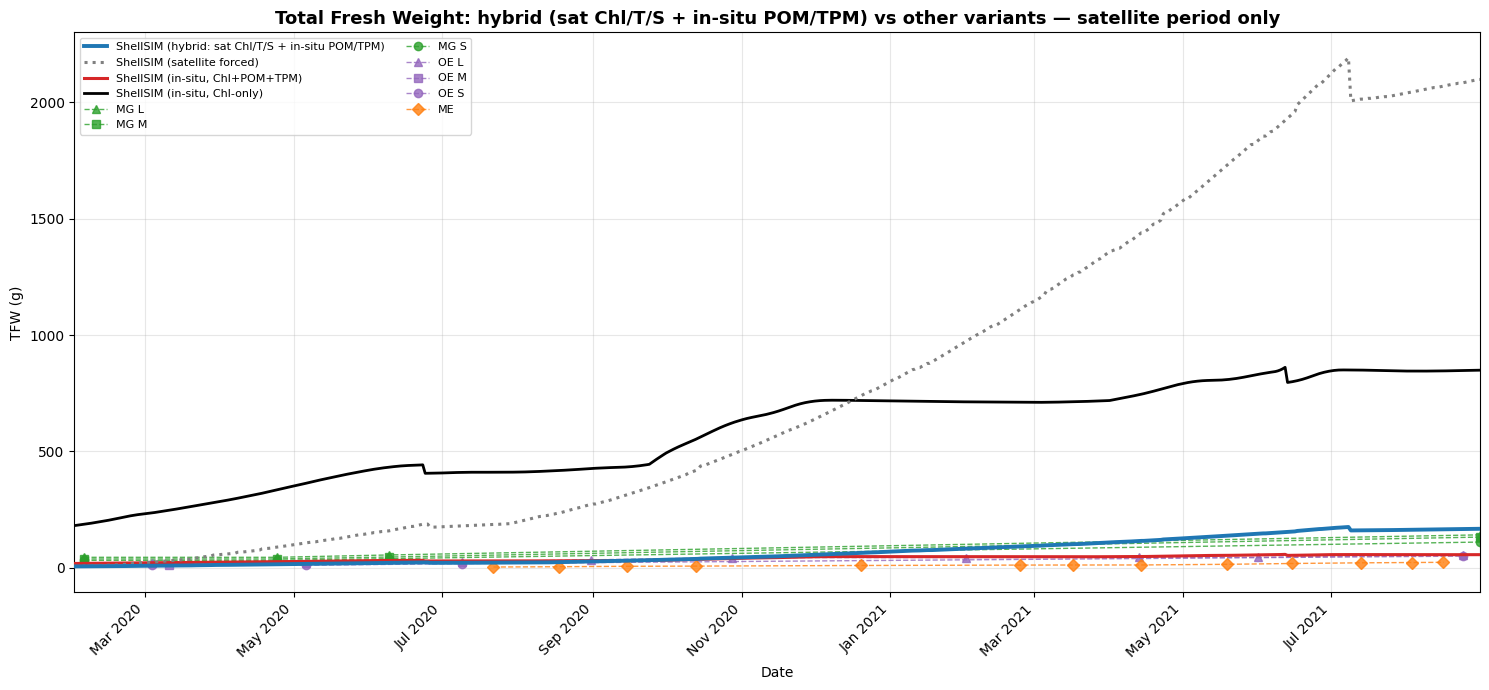

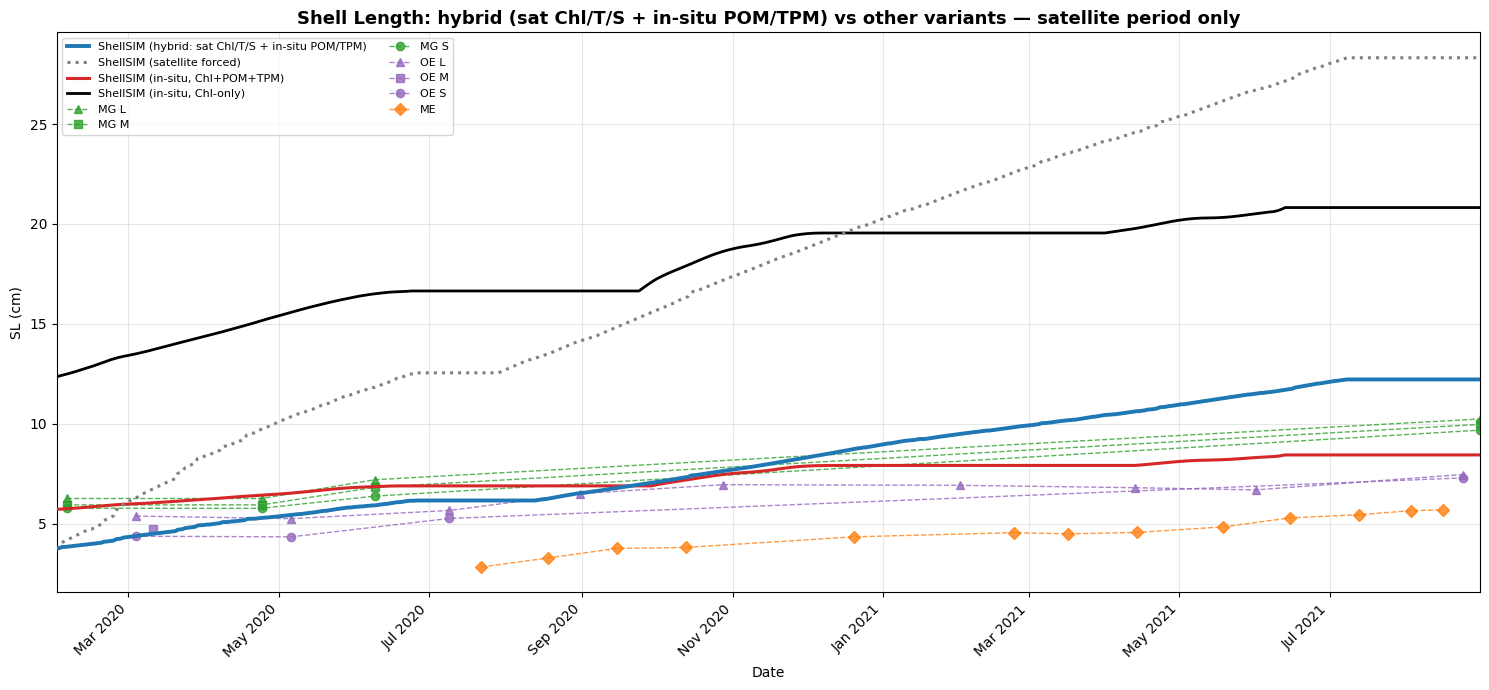

Max |hybrid - satellite-forced| over window (effect of adding in-situ POM/TPM): TFW=2018 g,  SL=16.1 cm
End-of-window TFW:  hybrid=166.8 g  |  satellite=2099.2 g


In [55]:
# ============================================================
# 4-LINE COMPARISON (satellite window only) vs IN-SITU GROWTH
#   1) ShellSIM HYBRID      (sat Chl/T/S + in-situ POM/TPM)   <- new
#   2) ShellSIM satellite    (sat Chl/T/S, no POM/TPM)
#   3) ShellSIM in-situ full (in-situ Chl + POM + TPM)
#   4) ShellSIM in-situ Chl-only
# Measured cohorts (MG / OE / ME) overlaid; x-axis clipped to the satellite period.
# ============================================================
win0, win1 = sat_horizon[0], sat_horizon[-1]

# (label, TFW series, SL series, colour, linestyle, lw, zorder)
model_lines = [
    ("ShellSIM (hybrid: sat Chl/T/S + in-situ POM/TPM)", model_tfw_hyb,  model_sl_hyb,  "tab:blue", "-", 2.8, 9),
    ("ShellSIM (satellite forced)",                      sat_tfw,        sat_sl,        "grey",     ":", 2.2, 8),
    ("ShellSIM (in-situ, Chl+POM+TPM)",                  model_tfw_full, model_sl_full, "tab:red",  "-", 2.2, 7),
    ("ShellSIM (in-situ, Chl-only)",                     model_tfw,      model_sl,      "black",    "-", 2.0, 6),
]

for metric, use_sl, ylab, title in [
    (TFW_METRIC, False, "TFW (g)", "Total Fresh Weight"),
    (SL_METRIC,  True,  "SL (cm)", "Shell Length"),
]:
    fig, ax = plt.subplots(figsize=(15, 7))
    for lbl, mtfw, msl, color, ls, lw, z in model_lines:
        s = msl if use_sl else mtfw
        if s is None:
            continue
        s = s[(s.index >= win0) & (s.index <= win1)]
        ax.plot(s.index, s.values, color=color, ls=ls, lw=lw, label=lbl, zorder=z)
    # measured cohorts (only points inside the satellite window)
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            d = pd.to_datetime(d); v = np.asarray(v, float)
            m = (d >= win0) & (d <= win1)
            if not m.any():
                continue
            lbl = f"{code} {sc}" if sc != "all" else code
            ax.plot(d[m], v[m], marker=size_markers.get(sc, "x"), ls="--", ms=6, lw=1.0,
                    color=species_colors[code], alpha=0.8, label=lbl)
    ax.set_xlim(win0, win1)
    ax.set_ylabel(ylab); ax.set_xlabel("Date")
    ax.set_title(f"{title}: hybrid (sat Chl/T/S + in-situ POM/TPM) vs other variants "
                 f"— satellite period only", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    for t in ax.get_xticklabels():
        t.set_rotation(45); t.set_ha("right")
    plt.tight_layout()
    plt.show()

# Clean apples-to-apples: hybrid and satellite share the same 5 g seed + start, so the
# difference between them is purely the effect of adding in-situ POM/TPM food limitation.
sat_tfw_win = sat_tfw.reindex(sat_horizon)
sat_sl_win  = sat_sl.reindex(sat_horizon)
dtfw_hs = float(np.nanmax(np.abs(model_tfw_hyb.values - sat_tfw_win.values)))
dsl_hs  = float(np.nanmax(np.abs(model_sl_hyb.values  - sat_sl_win.values)))
print(f"Max |hybrid - satellite-forced| over window (effect of adding in-situ POM/TPM): "
      f"TFW={dtfw_hs:.4g} g,  SL={dsl_hs:.4g} cm")
print(f"End-of-window TFW:  hybrid={model_tfw_hyb.iloc[-1]:.1f} g  |  satellite={sat_tfw_win.iloc[-1]:.1f} g")


In [56]:
# ============================================================
# SKILL TABLE over the SATELLITE WINDOW: hybrid vs the other variants
# (Reuses _score from sec.3; observations restricted to the satellite period.)
# ============================================================
hyb_variants = [
    ("hybrid",      model_tfw_hyb,  model_sl_hyb),
    ("satellite",   sat_tfw,        sat_sl),
    ("insitu_full", model_tfw_full, model_sl_full),
    ("insitu_chl",  model_tfw,      model_sl),
]
hyb_variants = [(n, t, s) for (n, t, s) in hyb_variants if t is not None]

def _score_win(model_series, dates, obs, lo, hi):
    """_score (sec.3) but only on observations inside [lo, hi]."""
    dates = pd.to_datetime(pd.Index(dates))
    obs = np.asarray(obs, float)
    m = (dates >= lo) & (dates <= hi)
    if not m.any():
        return None
    return _score(model_series, dates[m], obs[m])

rowsH = []
for metric, sl_flag in [(TFW_METRIC, False), (SL_METRIC, True)]:
    for code, df in insitu_bio.items():
        for sc in sorted(df["size_class"].unique()):
            d, v = get_insitu_series(df, metric, sc)
            if len(d) == 0:
                continue
            row = {"metric": metric, "species": code, "size_class": sc}
            ok = False
            for vname, mtfw, msl in hyb_variants:
                res = _score_win(msl if sl_flag else mtfw, d, v, win0, win1)
                if res is not None:
                    row[f"RMSE_{vname}"] = res["RMSE"]
                    row["n"] = res["n"]
                    ok = True
            if ok:
                rowsH.append(row)

cmpH = pd.DataFrame(rowsH)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
rmse_colsH = [c for c in cmpH.columns if c.startswith("RMSE_")]

for metric in [TFW_METRIC, SL_METRIC]:
    sub = cmpH[cmpH.metric == metric].copy()
    if sub.empty:
        continue
    sub = sub.sort_values("RMSE_hybrid").reset_index(drop=True)
    print(f"\n{'='*84}\n  {metric}: RMSE by variant over the SATELLITE window (lower = closer to cohort)\n{'='*84}")
    print(sub[["species", "size_class", "n"] + rmse_colsH].to_string(index=False))
    print("  Mean RMSE across cohorts:")
    for c in rmse_colsH:
        print(f"    {c:18s} = {sub[c].mean():.3f}")
    best = min(rmse_colsH, key=lambda c: sub[c].mean())
    print(f"  => Best forcing for {metric} over the satellite window: {best.replace('RMSE_','')}")

print("\nHybrid verdict guide (compare hybrid vs satellite — both seeded 5 g at 2020-02-01):")
print("  - hybrid ~= in-situ-full and << satellite  -> the satellite over-growth was the")
print("    MISSING POM/TPM food limitation; satellite Chl/T/S are themselves usable.")
print("  - hybrid still >> observations (tracks satellite) -> the satellite Chl/T/S")
print("    (esp. the high satellite Chl) inflate growth even WITH realistic POM/TPM.")



  TFW (g): RMSE by variant over the SATELLITE window (lower = closer to cohort)
species size_class  n  RMSE_hybrid  RMSE_satellite  RMSE_insitu_full  RMSE_insitu_chl
     OE          M  1        3.952          16.661             8.400          234.143
     MG          M  4       29.484         986.097            40.103          440.105
     MG          L  4       32.725         981.014            47.060          432.452
     MG          S  4       33.776         997.029            28.260          451.917
     OE          L  9       57.278        1075.869             5.234          576.368
     OE          S  4       58.326        1022.033            11.807          491.471
     ME        all 13       97.613        1376.387            33.050          686.462
  Mean RMSE across cohorts:
    RMSE_hybrid        = 44.736
    RMSE_satellite     = 922.156
    RMSE_insitu_full   = 24.845
    RMSE_insitu_chl    = 473.274
  => Best forcing for TFW (g) over the satellite window: insitu_full

  S